In [14]:
#importing the stuff that will be needed for the analysis
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
        accuracy_score, roc_curve, classification_report)
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
#read the dataset using pandas
dataset_test = pd.read_csv('test.csv')
dataset_test 

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,2,54,0,0,27.32,6.6,80,0,1,0,0,0,0,0,0,1,0
1,5,76,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0,0
2,10,32,0,0,27.32,5.0,100,0,1,0,0,0,0,0,1,0,0
3,17,15,0,0,30.36,6.1,200,0,0,1,0,0,0,0,1,0,0
4,30,43,0,0,26.08,6.1,155,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19218,99962,38,0,0,27.63,4.0,145,0,0,1,0,0,0,0,1,0,0
19219,99980,61,0,0,30.11,6.2,240,1,1,0,0,1,0,0,0,0,0
19220,99988,23,0,0,17.87,5.8,100,0,1,0,0,0,0,0,1,0,0
19221,99992,22,0,0,29.65,6.0,80,0,0,1,0,1,0,0,0,0,0


In [16]:
#read the datset using pandas
dataset_training = pd.read_csv('train.csv') 
dataset_training

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,63066,45,1,0,44.35,4.0,200,0,0,1,0,0,0,1,0,0,0
1,55713,45,0,1,29.95,6.0,158,0,0,1,0,1,0,0,0,0,0
2,76757,57,1,0,30.04,8.2,260,1,0,1,0,0,0,0,0,0,1
3,47140,80,0,0,24.29,6.2,158,0,1,0,0,0,0,0,0,0,1
4,48098,21,0,0,32.92,4.8,140,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76884,4327,50,0,0,35.41,4.8,126,0,0,1,0,0,0,0,1,0,0
76885,88698,24,0,0,24.79,6.0,155,0,1,0,0,0,0,0,1,0,0
76886,54442,60,0,0,37.79,6.5,159,1,0,1,0,0,0,1,0,0,0
76887,95902,12,0,0,27.32,6.0,145,0,1,0,0,0,0,0,0,1,0


In [17]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]
 
preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [18]:
train_scaled.head()  

,Unnamed: 0,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes,female,male,other,current,ever,former,never,no info,not current
0,0.476316,0.141014,2.521511,-1.429243,1.514969,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.221570,0.141014,0.390141,0.435572,0.486562,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.950644,0.674635,0.403462,2.486868,2.984121,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.075444,1.697407,-0.447605,0.622053,0.486562,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.042254,-0.926226,0.829736,-0.683317,0.045817,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [19]:
#set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
#dropping irrelevant columns as well because they don't have a large impact on the model
X_train = train_scaled.drop(['diabetes', 'no info', 'not current', 'HbA1c_level',
                        'former', 'never', 'ever', 'current', 'Unnamed: 0', 'other'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'HbA1c_level',
                        'never', 'ever', 'current', 'Unnamed: 0', 'other'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes'] 

In [20]:
X_test.head()

,age,bmi,blood_glucose_level,hypertension,heart_disease,female,male
0,0.541229,0.000870,-1.423335,0.0,0.0,1.0,0.0
1,1.519533,-1.061854,0.413105,1.0,1.0,0.0,1.0
2,-0.437074,0.000870,-0.933618,0.0,0.0,1.0,0.0
3,-1.193036,0.450826,1.514969,0.0,0.0,0.0,1.0
4,0.052078,-0.182664,0.413105,0.0,0.0,0.0,1.0


In [21]:
y_test.value_counts()

diabetes
0.0    17505
1.0     1718
Name: count, dtype: int64

In [22]:
#using the logistic regression, basic approach, function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [23]:
#setting threshold and prediction for the logistic regression
y_prob = lr.predict_proba(X_test)[:, 1]

threshold = 0.1
y_pred = (y_prob > threshold).astype(int)

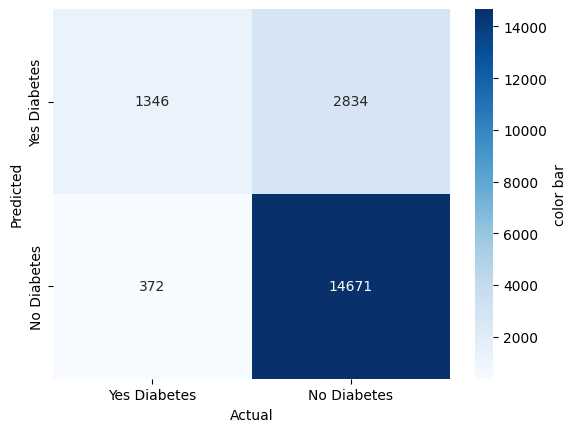


              precision    recall  f1-score   support

 No Diabetes       0.98      0.84      0.90     17505
    Diabetes       0.32      0.78      0.46      1718

    accuracy                           0.83     19223
   macro avg       0.65      0.81      0.68     19223
weighted avg       0.92      0.83      0.86     19223

                                0
Accuracy                 0.833221
Sensitivty               0.783469
Specificity              0.838103
AUC                      0.906370
Precision (No Diabetes)  0.975271
F1-Score (No Diabetes)   0.901499
Precision (Diabetes)     0.322010
F1-Score (Diabetes)      0.456426



In [ ]:
#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
#generate heatmap for the confusion matrix using seaborn
sns.heatmap((confusion_matrix(y_test, y_pred, labels=[1, 0])).T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
#plt.savefig("03: Heatmap for Confusion matrix")

plt.show()

#metrics definition
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 
sensitivity = tp / (tp + fn)

metrics_summary = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': roc_auc_score(y_test, y_prob),
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

#classification report giving metrics like sensitivity and specificity
print(classification_report(y_test, y_pred, target_names=['No Diabetes','Diabetes']))

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

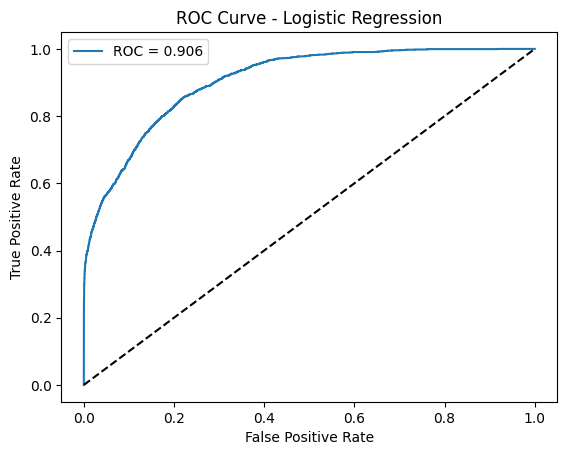

In [ ]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend() 
#plt.savefig("03: ROC Curve Logistic Rgeression")

plt.show() 

female                -1.402546
blood_glucose_level    1.358834
male                  -1.112227
age                    1.040439
hypertension           0.792852
heart_disease          0.706718
bmi                    0.598480
dtype: float64


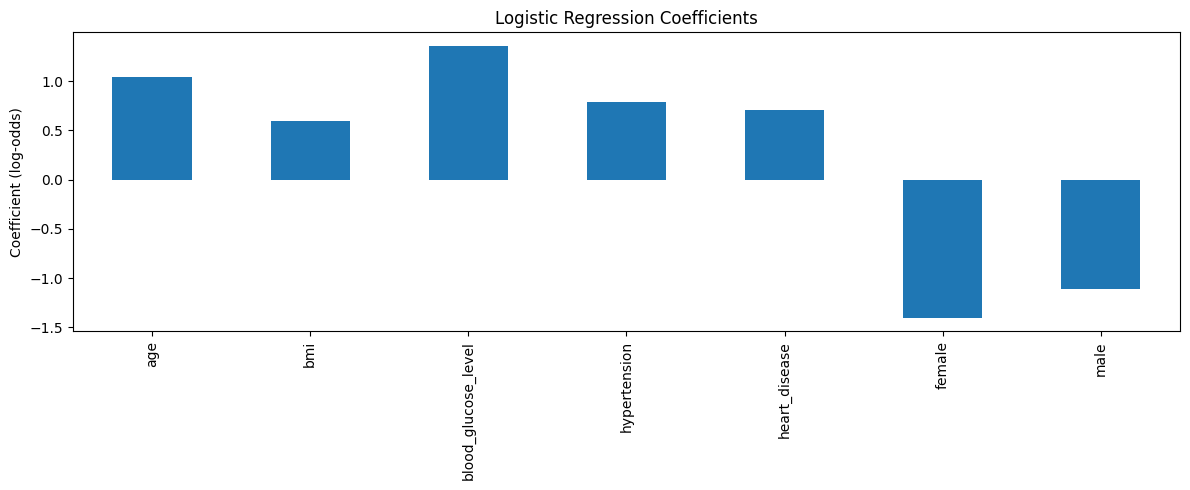

In [ ]:
#coefficients for each variable to see the relationship
coef  = pd.Series(lr.coef_[0], index=X_train.columns)
print(coef.sort_values(key=abs, ascending=False))

#coefficients plot for each variable
coef.plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
#plt.savefig("03: Coefficients plot Logistic Rgeression")

plt.show()